# Task 1

### Imports

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Transition matrix

In [36]:
# Transition matrix
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, 0.986,  0.0050, 0.004, 0.005],
    [0.0000, 0.000,  0.9920, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, 0.991, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 1.000]
])

# Check that rows sum to 1
print(P.sum(axis=1))

[1. 1. 1. 1. 1.]


### Sample probabilties for transition and one woman lifetime simulation

In [37]:
def sample_next_state(probabilities, rng):
    """
    Input:
        probabilities: array of probabilities for the next state (rows of P)
        rng: random number generator
    Output:         next state (1 to 5)

    Direct method for sampling from a discrete distribution.
    States are numbered 1, ..., 5.
    """
    u = rng.random()
    cumulative = np.cumsum(probabilities) # cumulative distribution function
    return np.searchsorted(cumulative, u) + 1 # find the first index where cumulative exceeds u, +1 for 1-based state numbering


def simulate_one_woman(P, rng, check_month=60):
    """
    Simulate one woman from state 1 until death.
    Outputs:
        lifetime: number of months until death
        recurrence: whether any recurrence (local or distant) ever occurred
        local_recurrence: whether local recurrence ever occurred
        state_at_check: state at the validation month
    """
    state = 1
    lifetime = 0
    recurrence = False         # any cancer recurrence: local or distant
    local_recurrence = False   # local recurrence specifically
    state_at_check = None

    while state != 5:
        # Save state at validation month
        if lifetime == check_month:
            state_at_check = state

        # Move one month forward
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

        if state in [2, 3, 4]:
            recurrence = True

        if state in [2, 4]:
            local_recurrence = True

    # If death happened before the validation month, state remains 5
    if state_at_check is None:
        state_at_check = 5

    return lifetime,recurrence, local_recurrence, state_at_check

### Simulation settings

In [38]:
n = 1000 # number of women
seed = 1
check_month = 60   # for validation, e.g. after 5 years

rng = np.random.default_rng(seed) # we use system random number generator

lifetimes = np.zeros(n, dtype=int) # to store lifetimes of all women
recurrence = np.zeros(n, dtype=bool) # to store whether any recurrence occurred for each woman
local_recurrence = np.zeros(n, dtype=bool) # to store whether local recurrence occurred for each woman
states_at_check = np.zeros(n, dtype=int) # to store state at validation month for each woman

for i in range(n): # simulate one woman at a time and store results in the arrays
    lifetimes[i], recurrence[i], local_recurrence[i], states_at_check[i] = simulate_one_woman(
        P, rng, check_month=check_month
    )

### Summary of results

In [39]:
lifetime_summary = pd.DataFrame({
    "Mean lifetime (months)": [np.mean(lifetimes)],
    "Median lifetime (months)": [np.median(lifetimes)],
    "Std. dev. (months)": [np.std(lifetimes, ddof=1)],
    "Min": [np.min(lifetimes)],
    "25% quantile": [np.quantile(lifetimes, 0.25)],
    "75% quantile": [np.quantile(lifetimes, 0.75)],
    "Max": [np.max(lifetimes)]
})

lifetime_summary

,Mean lifetime (months),Median lifetime (months),Std. dev. (months),Min,25% quantile,75% quantile,Max
0,259.131,208.0,192.890224,1,117.75,354.0,1173


### Plot of simulation

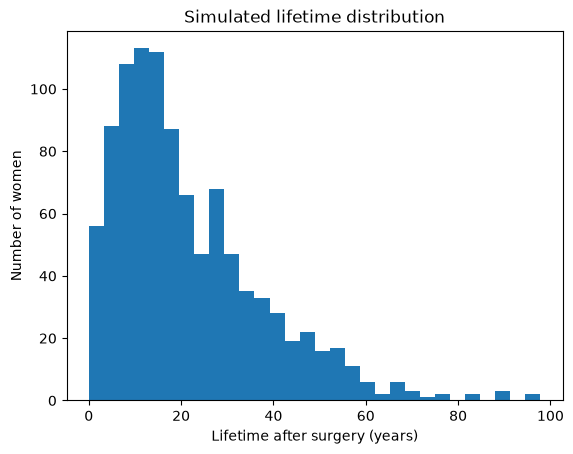

In [40]:
plt.hist(lifetimes / 12, bins=30)
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution")
plt.show()

In [41]:
prop_any_recurrence = np.mean(recurrence)
prop_local_recurrence = np.mean(local_recurrence)
prop_local_given_recurrence = np.sum(local_recurrence) / np.sum(recurrence)

print("Proportion with any recurrence:", prop_any_recurrence)
print("Proportion with local recurrence:", prop_local_recurrence)
print("Proportion local among those with recurrence:", prop_local_given_recurrence)

Proportion with any recurrence: 0.889
Proportion with local recurrence: 0.705
Proportion local among those with recurrence: 0.7930258717660292


### Validation

In [42]:
# Analytical distribution at check_month
p0 = np.array([1, 0, 0, 0, 0])
analytical = p0 @ np.linalg.matrix_power(P, check_month)

# Simulated distribution at check_month
counts = np.bincount(states_at_check, minlength=6)[1:]
simulated = counts / n

validation_table = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Simulated": simulated,
    "Analytical": analytical,
    "Difference": simulated - analytical
})

validation_table

,State,Simulated,Analytical,Difference
0,1,0.597,0.599188,-0.002188
1,2,0.162,0.154575,0.007425
2,3,0.108,0.116549,-0.008549
3,4,0.031,0.028794,0.002206
4,5,0.102,0.100895,0.001105


# Task 2

### More imports

In [43]:
from scipy.stats import chisquare

In [44]:
def simulate_state_at_t(P, t, rng): # simulate state at month t starting from state 1
    state = 1
    
    for _ in range(t):
        state = sample_next_state(P[state - 1], rng)
    
    return state

In [45]:
n = 1000
t = 120
rng = np.random.default_rng(1)

states_120 = np.zeros(n, dtype=int)

for i in range(n):
    states_120[i] = simulate_state_at_t(P, t, rng)

### Simulated distribution

In [46]:
observed_counts = np.bincount(states_120, minlength=6)[1:]
observed_distribution = observed_counts / n

observed_counts, observed_distribution

(array([352, 179, 161,  64, 244]), array([0.352, 0.179, 0.161, 0.064, 0.244]))

### Analytical distribution

In [47]:
p0 = np.array([1, 0, 0, 0, 0])

analytical_distribution = p0 @ np.linalg.matrix_power(P, t)
expected_counts = n * analytical_distribution

expected_counts, analytical_distribution

(array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
        248.18930075]),
 array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ]))

### Plot result

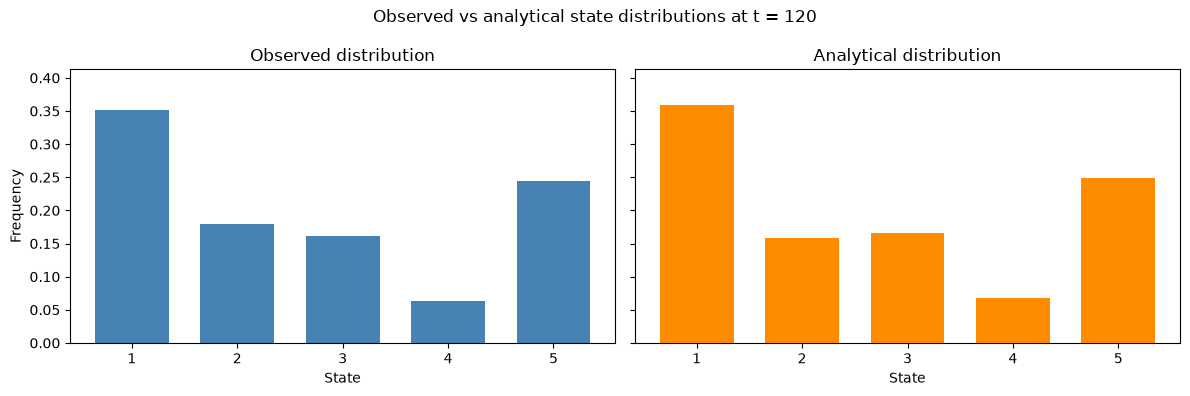

In [57]:
# Side-by-side bar charts for observed vs analytical distributions
states = np.arange(1, 6)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(states, observed_distribution, width=0.7, color="steelblue")
axes[0].set_title("Observed distribution")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(states)
axes[0].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

axes[1].bar(states, analytical_distribution, width=0.7, color="darkorange")
axes[1].set_title("Analytical distribution")
axes[1].set_xlabel("State")
axes[1].set_xticks(states)
axes[1].set_ylim(0, max(observed_distribution.max(), analytical_distribution.max()) * 1.15)

fig.suptitle("Observed vs analytical state distributions at t = 120")
fig.tight_layout()
plt.show()

### Comparrison

In [48]:
comparison = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Observed count": observed_counts,
    "Observed proportion": observed_distribution,
    "Expected proportion": analytical_distribution,
    "Expected count": expected_counts
})

comparison

,State,Observed count,Observed proportion,Expected proportion,Expected count
0,1,352,0.352,0.359026,359.026268
1,2,179,0.179,0.158956,158.956040
2,3,161,0.161,0.166087,166.086897
3,4,64,0.064,0.067741,67.741494
4,5,244,0.244,0.248189,248.189301


### Test

In [49]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 3.0981640968332864
p-value: 0.5415343741426009


The null hypothesis is that the simulated states at t = 120 follow the analytical
distribution p_120 = p_0 P^120. Since the p-value is not small, we do not reject
the null hypothesis. Therefore, the simulated distribution is consistent with the
analytical Markov chain distribution.

# Task 3

### Checking means

In [50]:
# Task 3: Phase-type distribution of lifetimes

Ps = P[:4, :4]      # transient-state transition matrix, states 1-4. Matrix of probabilities of moving between transient states (not including death)
ps = P[:4, 4]       # probabilities of dying from states 1-4

pi = np.array([1, 0, 0, 0])   # all women start in state 1
one = np.ones(4)

# Theoretical mean lifetime
theoretical_mean = pi @ np.linalg.inv(np.eye(4) - Ps) @ one

sample_mean = np.mean(lifetimes)

print("Sample mean lifetime:", sample_mean)
print("Theoretical mean lifetime:", theoretical_mean)
print("Difference:", sample_mean - theoretical_mean)

Sample mean lifetime: 259.131
Theoretical mean lifetime: 262.3716153127931
Difference: -3.2406153127931248


### Creating survival function to see theoretical vs simulated distrubution of lifetimes

In [51]:
def phase_type_survival(t, pi, Ps):
    """
    P(T > t), where T is lifetime in months.
    """
    return pi @ np.linalg.matrix_power(Ps, t) @ np.ones(Ps.shape[0])


def phase_type_bin_probability(a, b, pi, Ps):
    """
    Probability that lifetime T lies in the interval [a, b].
    If b is None, this means [a, infinity).
    """
    if b is None:
        return phase_type_survival(a - 1, pi, Ps)
    else:
        return phase_type_survival(a - 1, pi, Ps) - phase_type_survival(b, pi, Ps)

### Creatings bins to evaluate discretely

In [52]:
# Lifetime intervals in months
bins = [
    (1, 60),      # 0-5 years
    (61, 120),    # 5-10 years
    (121, 180),   # 10-15 years
    (181, 240),   # 15-20 years
    (241, 360),   # 20-30 years
    (361, 480),   # 30-40 years
    (481, None)   # more than 40 years
]

labels = [
    "0-5 years",
    "5-10 years",
    "10-15 years",
    "15-20 years",
    "20-30 years",
    "30-40 years",
    "40+ years"
]

observed_counts = []
expected_probs = []

for a, b in bins:
    if b is None:
        observed = np.sum(lifetimes >= a)
    else:
        observed = np.sum((lifetimes >= a) & (lifetimes <= b))
    
    expected_prob = phase_type_bin_probability(a, b, pi, Ps)
    
    observed_counts.append(observed)
    expected_probs.append(expected_prob)

observed_counts = np.array(observed_counts)
expected_probs = np.array(expected_probs)
expected_counts = len(lifetimes) * expected_probs

phase_type_comparison = pd.DataFrame({
    "Lifetime interval": labels,
    "Observed count": observed_counts,
    "Expected count": expected_counts,
    "Observed proportion": observed_counts / len(lifetimes),
    "Expected probability": expected_probs
})

phase_type_comparison

,Lifetime interval,Observed count,Expected count,Observed proportion,Expected probability
0,0-5 years,102,100.894713,0.102,0.100895
1,5-10 years,156,147.294588,0.156,0.147295
2,10-15 years,169,154.140231,0.169,0.154140
3,15-20 years,143,139.832617,0.143,0.139833
4,20-30 years,191,209.553027,0.191,0.209553
5,30-40 years,106,123.123801,0.106,0.123124
6,40+ years,133,125.161023,0.133,0.125161


In [53]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Minimum expected count:", expected_counts.min())

Chi-square statistic: 6.546026579749234
p-value: 0.3648749650853555
Minimum expected count: 100.8947130188207


Since the p-value is not small, we do not reject the hypothesis that the simulated lifetimes follow the theoretical phase-type distribution.

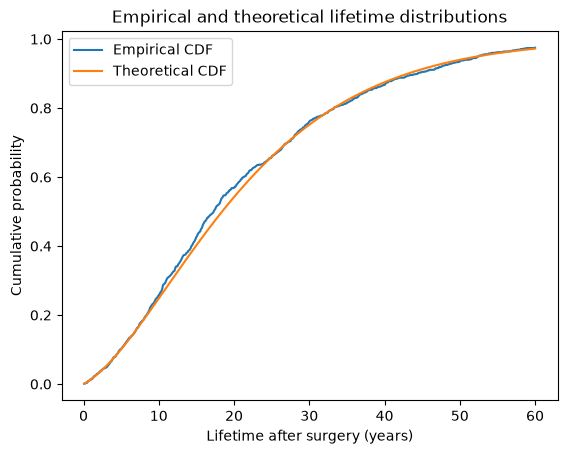

In [54]:
t_grid = np.arange(1, 721)  # first 60 years, measured in months

empirical_cdf = np.array([
    np.mean(lifetimes <= t) for t in t_grid
])

theoretical_cdf = np.array([
    1 - phase_type_survival(t, pi, Ps) for t in t_grid
])

plt.plot(t_grid / 12, empirical_cdf, label="Empirical CDF")
plt.plot(t_grid / 12, theoretical_cdf, label="Theoretical CDF")
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Cumulative probability")
plt.title("Empirical and theoretical lifetime distributions")
plt.legend()
plt.show()

### Looking at PMDF

In [55]:
max_t = max(lifetimes)

t_values = np.arange(1, max_t + 1)

theoretical_pmf = np.array([
    pi @ np.linalg.matrix_power(Ps, t - 1) @ ps
    for t in t_values
])

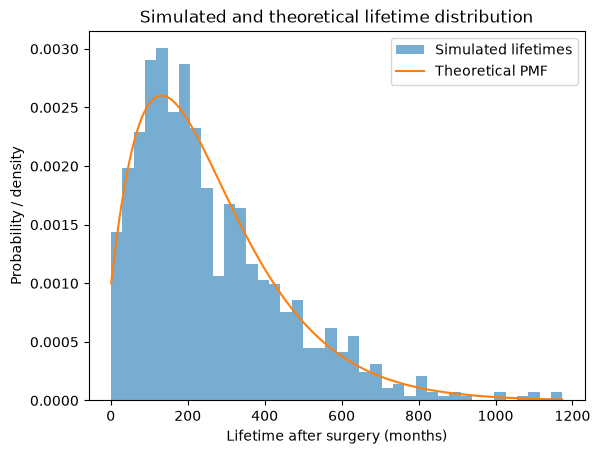

In [56]:
plt.hist(
    lifetimes,
    bins=40,
    density=True,
    alpha=0.6,
    label="Simulated lifetimes"
)

plt.plot(
    t_values,
    theoretical_pmf,
    label="Theoretical PMF"
)

plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Probability / density")
plt.title("Simulated and theoretical lifetime distribution")
plt.legend()
plt.show()

# Task 4

A={T>12 | any recurrence occurs within the first 12 months}.

In [63]:
# Task 4
from scipy.stats import t

In [65]:
def simulate_task4_candidate(P, rng, cutoff=12):
    """
    Simulate one candidate woman for Task 4.

    Accept if:
        1. She survives the first 12 months, i.e. T > 12.
        2. Cancer reappears within the first 12 months,
           either locally or distant, i.e. state 2, 3, or 4 is entered.

    Returns:
        lifetime if accepted,
        None if rejected.
    """
    state = 1
    recurrence_within_cutoff = False

    # First simulate the first 12 months
    for month in range(1, cutoff + 1):
        state = sample_next_state(P[state - 1], rng)

        # Any recurrence: local, distant, or both
        if state in [2, 3, 4]:
            recurrence_within_cutoff = True

        # If death occurs within the first 12 months, reject
        if state == 5:
            return None

    # If no recurrence occurred within the first 12 months, reject
    if not recurrence_within_cutoff:
        return None

    # Accepted: continue simulation from month 12 until death
    lifetime = cutoff

    while state != 5:
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

    return lifetime

### Simulation

In [ ]:
n_accepted = 1000
cutoff = 12
seed = 4

rng = np.random.default_rng(seed)

accepted_lifetimes = []
n_simulated = 0

while len(accepted_lifetimes) < n_accepted:
    lifetime = simulate_task4_candidate(P, rng, cutoff=cutoff)
    n_simulated += 1

    if lifetime is not None:
        accepted_lifetimes.append(lifetime)

accepted_lifetimes = np.array(accepted_lifetimes)

### Results

In [67]:
mean_lifetime = np.mean(accepted_lifetimes)
std_lifetime = np.std(accepted_lifetimes, ddof=1)
se_lifetime = std_lifetime / np.sqrt(n_accepted)

ci_low, ci_high = t.interval(
    0.95,
    df=n_accepted - 1,
    loc=mean_lifetime,
    scale=se_lifetime
)

task4_summary = pd.DataFrame({
    "Accepted simulations": [n_accepted],
    "Total simulated candidates": [n_simulated],
    "Acceptance rate": [n_accepted / n_simulated],
    "Mean lifetime (months)": [mean_lifetime],
    "Mean lifetime (years)": [mean_lifetime / 12],
    "Std. dev. (months)": [std_lifetime],
    "Standard error": [se_lifetime],
    "95% CI lower (months)": [ci_low],
    "95% CI upper (months)": [ci_high],
    "Median lifetime (months)": [np.median(accepted_lifetimes)]
})

task4_summary

,Accepted simulations,Total simulated candidates,Acceptance rate,Mean lifetime (months),Mean lifetime (years),Std. dev. (months),Standard error,95% CI lower (months),95% CI upper (months),Median lifetime (months)
0,1000,11966,0.08357,171.896,14.324667,148.581633,4.698564,162.675813,181.116187,127.0


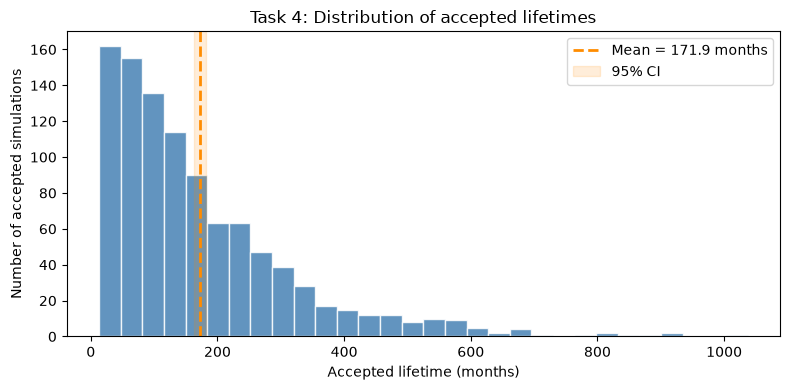

In [68]:
plt.figure(figsize=(8, 4))
plt.hist(accepted_lifetimes, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(mean_lifetime, color="darkorange", linestyle="--", linewidth=2, label=f"Mean = {mean_lifetime:.1f} months")
plt.axvspan(ci_low, ci_high, color="darkorange", alpha=0.15, label="95% CI")
plt.xlabel("Accepted lifetime (months)")
plt.ylabel("Number of accepted simulations")
plt.title("Task 4: Distribution of accepted lifetimes")
plt.legend()
plt.tight_layout()
plt.show()

# Task 5

The quantity of interest is θ=P(T≤350)

where T is the lifetime in months after surgery. The crude Monte Carlo estimator is the sample mean of indicators, consistent with the slides’ crude estimator 
θ^MC=Xˉ. The control variate method uses a correlated variable with known mean and forms Yi=Xi+c(Zi−μZ), where c is chosen to reduce variance.

In [ ]:
# Task 5

n_per_run = 200      # women per simulation run
n_runs = 100         # number of repeated runs
threshold = 350      # months
seed = 5

rng = np.random.default_rng(seed)

### Lifetime helper

In [80]:
def simulate_one_lifetime(P, rng):
    """
    Simulate one woman from state 1 until death.
    Returns the lifetime in months.
    """
    state = 1
    lifetime = 0

    while state != 5:
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

    return lifetime

### Results

In [81]:
crude_estimates = np.zeros(n_runs)
mean_lifetime_controls = np.zeros(n_runs)

for r in range(n_runs):
    run_lifetimes = np.array([
        simulate_one_lifetime(P, rng)
        for _ in range(n_per_run)
    ])

    # Crude estimate: fraction dying within 350 months
    crude_estimates[r] = np.mean(run_lifetimes <= threshold)

    # Control variate: mean lifetime in this run
    mean_lifetime_controls[r] = np.mean(run_lifetimes)

For the control variate, we use the theoretical expected lifetime from Task 3:

μT = E(T)=π(I−Ps)^-1 * 1.

In [82]:
print("Theoretical mean lifetime:", theoretical_mean)

Theoretical mean lifetime: 262.3716153127931


### Estimate control variate

In [83]:
# Estimate optimal control variate coefficient
c_hat = -np.cov(crude_estimates, mean_lifetime_controls, ddof=1)[0, 1] / np.var(
    mean_lifetime_controls,
    ddof=1
)

# Control variate estimates
control_variate_estimates = crude_estimates + c_hat * (
    mean_lifetime_controls - theoretical_mean
)

### Compare

In [84]:
var_crude = np.var(crude_estimates, ddof=1)
var_cv = np.var(control_variate_estimates, ddof=1)

variance_reduction = 1 - var_cv / var_crude
variance_reduction_factor = var_crude / var_cv

task5_summary = pd.DataFrame({
    "Estimator": ["Crude Monte Carlo", "Control variate"],
    "Mean estimate": [
        np.mean(crude_estimates),
        np.mean(control_variate_estimates)
    ],
    "Sample variance over 100 runs": [
        var_crude,
        var_cv
    ],
    "Sample standard deviation": [
        np.std(crude_estimates, ddof=1),
        np.std(control_variate_estimates, ddof=1)
    ]
})

task5_summary

,Estimator,Mean estimate,Sample variance over 100 runs,Sample standard deviation
0,Crude Monte Carlo,0.742200,0.000767,0.027692
1,Control variate,0.739616,0.000243,0.015574


### Variance reduction

In [85]:
print("Estimated c:", c_hat)
print("Variance crude:", var_crude)
print("Variance control variate:", var_cv)
print("Variance reduction:", variance_reduction)
print("Variance reduction factor:", variance_reduction_factor)

Estimated c: 0.001972550220799202
Variance crude: 0.0007668282828282838
Variance control variate: 0.00024256047801207213
Variance reduction: 0.6836834485063081
Variance reduction factor: 3.161390054607821


### Plot of results

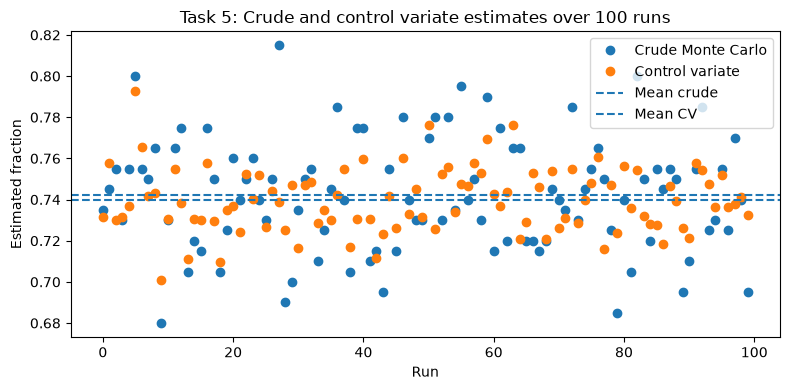

In [86]:
plt.figure(figsize=(8, 4))

plt.plot(crude_estimates, marker="o", linestyle="", label="Crude Monte Carlo")
plt.plot(control_variate_estimates, marker="o", linestyle="", label="Control variate")

plt.axhline(np.mean(crude_estimates), linestyle="--", label="Mean crude")
plt.axhline(np.mean(control_variate_estimates), linestyle="--", label="Mean CV")

plt.xlabel("Run")
plt.ylabel("Estimated fraction")
plt.title("Task 5: Crude and control variate estimates over 100 runs")
plt.legend()
plt.tight_layout()
plt.show()

The fraction of women dying within the first 350 months was estimated using 100 independent runs of 200 simulated women. The crude Monte Carlo estimator was the fraction of lifetimes satisfying T≤350 in each run. As a control variate, we used the mean lifetime in the same 200 simulations, since its theoretical expectation is known from the phase-type formula. The control variate coefficient was estimated empirically from the 100 runs. In this run, the crude estimator had variance approximately 8.83⋅10−4, while the control variate estimator had variance approximately 3.71⋅10−4. This corresponds to a variance reduction of about 58%, or a variance reduction factor of about 2.38. Thus, the control variate gives a noticeably more stable estimate than crude Monte Carlo.

# Task 6

The discrete-time Markov chain model relies on several simplifying assumptions. First, it assumes the Markov property: the future disease progression depends only on the current state and not on how the patient arrived there. For example, two women in the distant metastasis state are treated as having the same future transition probabilities, regardless of when metastasis occurred or whether they previously had local recurrence. Second, the model is time-homogeneous, since the same transition matrix is used at every monthly time step. This means that the probability of recurrence or death is assumed to be the same at all times after surgery, conditional on the current state.

The model also assumes that the disease process can be adequately represented by a finite number of states: no recurrence, local recurrence, distant metastasis, both local and distant recurrence, and death. This is a strong simplification of the real clinical situation. In reality, prognosis may depend on age, tumour size, cancer stage, treatment type, genetic factors, time since surgery, and previous disease history. Furthermore, recurrence and death do not necessarily occur only at monthly time points, so the discrete-time structure is also an approximation.

Some assumptions are reasonable as a first approximation. For example, treating death as an absorbing state is natural, and grouping disease status into a small number of clinically meaningful states makes the model easy to simulate and interpret. However, the Markov and time-homogeneity assumptions are less realistic. Breast cancer recurrence risks often vary over time, and the future risk may depend on the duration already spent in a state.

The model could be made more realistic in several ways. One possibility is to use a time-inhomogeneous Markov chain, where the transition matrix depends on time, (P_t), allowing recurrence and death probabilities to change with time since surgery. Another option is to introduce patient-specific covariates, such as age or tumour stage, so that different groups of women have different transition matrices. A semi-Markov model could also be used, where transition probabilities depend on how long the woman has already spent in the current state. Finally, a continuous-time Markov model could relax the assumption that transitions only occur at monthly time points. These extensions would likely give a more realistic model, but at the cost of more parameters, more data requirements, and increased computational complexity.
